LEZIONE 1:
PREPARAZIONE DELLA PIPELINE PER PULIRE I VALORI NAN DELL DF
============================================================

In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor


In [3]:
df = pd.read_csv ('C:\\Users\\ilfra\\Desktop\\progetti Aesys\\model_selection\\Dataset\\raw\\housing.csv')

In [4]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

df = pd.read_csv('C:\\Users\\ilfra\\Desktop\\progetti Aesys\\model_selection\\Dataset\\raw\\housing.csv')
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

num_features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
cat_features = ['ocean_proximity']

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features),
    ('cat', Pipeline([('onehot', OneHotEncoder(drop='first', sparse_output=False))]), cat_features)
])

X_processed = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print("✅ Dati pronti!")
print(f"X_train shape: {X_train.shape}")


✅ Dati pronti!
X_train shape: (16512, 12)


LEZIONE 2:
PROVIAMO I VARI REGRESSORI FACENDO DEI DICTIONARY CONCATENATI
=============================================================

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

REGRESSORS = {

    "LinearRegression": {
        "model": LinearRegression,
        "params": {}
    },

    "DecisionTree": {
        "model": DecisionTreeRegressor,
        "params": {"max_depth": 5, "random_state": 42}
    },

    "RandomForest": {
        "model": RandomForestRegressor,
        "params": {"n_estimators": 100, "random_state": 42}
    },

    "XGBoost": {
        "model": XGBRegressor,
        "params": {"n_estimators": 100, "learning_rate": 0.1, "random_state": 42}
    }

}


In [6]:
import numpy as np
from sklearn.metrics import mean_squared_error

# =================================
# 1. SPLIT 80/20 - RMSE Test Set
# =================================
print(" SPLIT 80/20 - RMSE Test Set")
rmse_split = {}

for nome, config in REGRESSORS.items():
    print(f"Testing {nome}...", end=" ")
    
    model = config["model"](**config["params"])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_split[nome] = rmse
    print(f"{rmse:.4f}")

# Migliore split
best_split = min(rmse_split, key=rmse_split.get)
print(f"\n🏆 Migliore SPLIT: {best_split} (RMSE: {rmse_split[best_split]:.4f})")

 SPLIT 80/20 - RMSE Test Set
Testing LinearRegression... 70060.5218
Testing DecisionTree... 71510.9005
Testing RandomForest... 49034.5748
Testing XGBoost... 48655.5877

🏆 Migliore SPLIT: XGBoost (RMSE: 48655.5877)


In [7]:
import numpy as np
from sklearn.model_selection import cross_val_score

# =================================
# 1. CROSS-VALIDATION 5-fold - RMSE Medio
# =================================
print(" CROSS-VALIDATION 5-fold - RMSE Medio")
rmse_cv = {}

# Dati completi preprocessati (da funzione o pipeline)
X_full = preprocessor.fit_transform(X)  # O dal tuo get_processed_data()
y_full = y

for nome, config in REGRESSORS.items():
    print(f"Testing {nome}...", end=" ")
    
    model = config["model"](**config["params"])
    
    # CV automatico: 5 fold
    scores = cross_val_score(
        model, X_full, y_full, 
        cv=5, 
        scoring='neg_root_mean_squared_error'
    )
    
    rmse = -scores.mean()  # Media RMSE
    rmse_cv[nome] = rmse
    print(f"{rmse:.4f}")

# Migliore CV
best_cv = min(rmse_cv, key=rmse_cv.get)
print(f"\n🏆 Migliore CV: {best_cv} (RMSE: {rmse_cv[best_cv]:.4f})")


 CROSS-VALIDATION 5-fold - RMSE Medio
Testing LinearRegression... 73719.6869
Testing DecisionTree... 83677.4040
Testing RandomForest... 76640.4175
Testing XGBoost... 68496.5932

🏆 Migliore CV: XGBoost (RMSE: 68496.5932)


LEZIONE 3:
GRIDSEARCH PER TROVARE I MIGLIORI PARAMETRI
===============================================

Vedendo che xgb boost è il migliore ora facciamo una gridsearch per trovare la situazione migliore


In [8]:
from sklearn.model_selection import GridSearchCV
import numpy as np

In [9]:
X_full= preprocessor.fit_transform(X)  # 
y_full = y

xgb_base = XGBRegressor(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],#variamo il numero di alberi per vedere se migliora la performance
    'learning_rate': [0.05, 0.1, 0.2], #variamo il learning rate per vedere se migliora la performance
    'max_depth': [3, 5, 7]#variamo la profondità massima degli alberi per vedere se migliora la performance
}

grid_search = GridSearchCV(
    estimator=xgb_base,# il modello base da ottimizzare
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    scoring='neg_root_mean_squared_error', # metrica di valutazione
    n_jobs=-1,#per fare più velocemente la ricerca usiamo tutti i core disponibili
    verbose=1#per vedere i progressi della ricerca
)

In [10]:
grid_search.fit(X_full, y_full)#faccio partire la ricerca dei migliori parametri su tutti i dati preprocessati (X_full, y_full)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter ca

In [11]:
print("Migliori parametri:", grid_search.best_params_)
print("Miglior score:", -grid_search.best_score_)
#mettiamo il segno negativo per avere il RMSE positivo, visto che abbiamo usato 'neg_root_mean_squared_error' 
bestxgb = grid_search.best_estimator_

Migliori parametri: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
Miglior score: 66294.90775210448


In [12]:
y_pred_test = bestxgb.predict(X_test) 

#calcoliamo il RMSE sui dati di test con i migliori parametri trovati da GridSearchCV
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
print("RMSE Test con migliori params:", rmse_test)

RMSE Test con migliori params: 45771.73931917097


DOPO AVERLO PROVATO, GIA CHE CI SONO PROVO A METTERE PARAMETRI CHE CERCANDO POSSONO MIGLIORARLO ANCORA DI PIù PER ARRIVARE A SCENDERE SOTTO AL 45K E DOPO PROVO A MIGLIORARE IL RANDOM FOREST

In [13]:
xgb_v2 = XGBRegressor(random_state=42)

# param_grid_v2: Espansione intelligente intorno ai tuoi best_params
param_grid_v2 = {
    'n_estimators': [200, 300, 400],           # Più alberi del tuo 200
    'learning_rate': [0.08, 0.1, 0.12],        # Intorno al tuo 0.1
    'max_depth': [5, 6, 7],                    # Dal tuo 5 → poco più profondo
    'subsample': [0.85, 0.9],                  # **NUOVO**: Anti-overfitting
    'colsample_bytree': [0.85, 0.9],           # **NUOVO**: Campiona feature
    'reg_alpha': [0, 0.1],                     # **NUOVO**: Regolarizzazione L1
    'reg_lambda': [1, 1.5]                     # **NUOVO**: Regolarizzazione L2
}

print(" GRIDSEARCH V2 per RMSE <45k...")
grid_v2 = GridSearchCV(
    xgb_v2,
    param_grid_v2,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,                    
    verbose=2
)

 GRIDSEARCH V2 per RMSE <45k...


In [69]:
grid_v2.fit(X_train, y_train)#faccio partire la ricerca dei migliori parametri su tutti i dati preprocessati (X_full, y_full)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.85, 0.9], 'learning_rate': [0.08, 0.1, ...], 'max_depth': [5, 6, ...], 'n_estimators': [200, 300, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computat

In [70]:
print("\n V2 Migliori parametri:", grid_v2.best_params_)
print("V2 RMSE CV:", -grid_v2.best_score_)
best_v2 = grid_v2.best_estimator_



 V2 Migliori parametri: {'colsample_bytree': 0.85, 'learning_rate': 0.08, 'max_depth': 6, 'n_estimators': 400, 'reg_alpha': 0, 'reg_lambda': 1.5, 'subsample': 0.85}
V2 RMSE CV: 45343.00430950058


VISTO CHE PER FARE IL FIT DI QUESTO MODELLO CI VORRà PIù TEMPO DEL SOLITO (CIRCA 3/4 MINUTI) PER VEDERE I RISULTATI METTO LA FOTO NELLA CARTELLA

In [16]:
y_pred_v2 = best_v2.predict(X_test)

rmse_v2 = np.sqrt(mean_squared_error(y_test, y_pred_v2))

print(" V2 RMSE Test:", rmse_v2)

 V2 RMSE Test: 36247.59300183496


COME SI VEDE SIAMO RIUSCITI NEL MIGLIORARE IL MODELLO, V2 RMSE Test: 36247.59300183496

LEZIONE 4: FEATURE ENGINEERING
=======

PER MIGLIORARE QUESTO SCRIPT INIZIO A STUDIARE LE BASI PER LA FEATURE ENGINEERING SU KAGGLE

In [17]:
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt

In [18]:
X_mi = X.copy()
#tramite questo ciclo trasformo le variabili categoriche in numeriche con il factorize, 
# per evitare di controllare ogni volta le variabili stringhe
for colname in X_mi.select_dtypes(["object", "category"]):
    X_mi[colname], _ = X_mi[colname].factorize()

discrete_features = X_mi.dtypes == int#troviamo anche quelle che sono discrete (interi) per la MI

# B. Gestione NaN perchè aveva trovato alune NaN
imputer = SimpleImputer(strategy='median')
X_mi = pd.DataFrame(imputer.fit_transform(X_mi), columns=X_mi.columns)

# Identifichiamo quali colonne sono discrete (interi)
discrete_features = (X_mi.dtypes == int)

C:\Users\ilfra\AppData\Local\Temp\ipykernel_5140\584514871.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for colname in X_mi.select_dtypes(["object", "category"]):


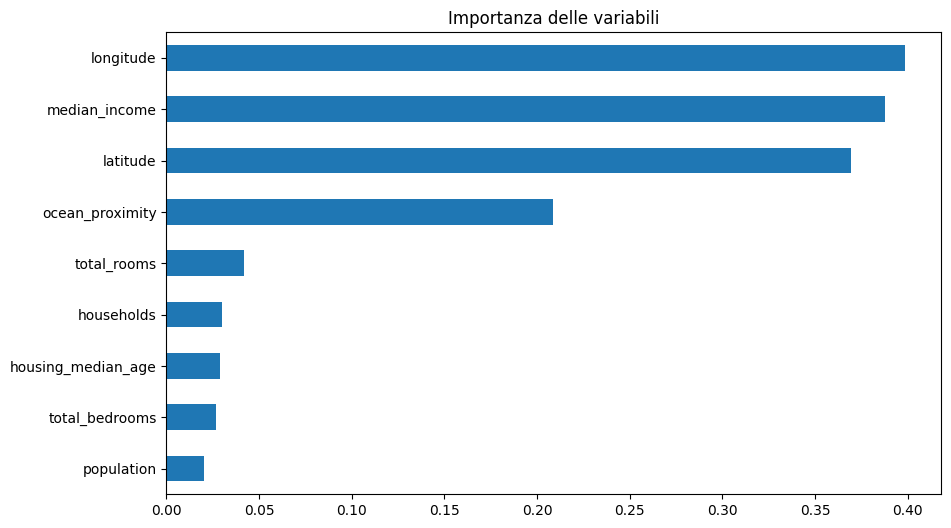

In [19]:
#DIRETTAMENTE DA KAGGLE

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=42)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X_mi, y, discrete_features)

plt.figure(figsize=(10, 6), dpi=100)
mi_scores.sort_values(ascending=True).plot(kind='barh')
plt.title("Importanza delle variabili")
plt.show()


In [20]:
#vedendo i valori ricevuti dal grafico possiamo trovare delle buone combinazioni fra le cose più significanti 
df["income_per_area"]= df.groupby(['longitude', 'latitude'])["median_income"].transform("mean")
#creiamo una nuova variabile che rappresenta il reddito medio per area, 
# raggruppando per longitudine e latitudine e calcolando la media del reddito in quelle aree.

# interazione posizione + reddito (Lezione 5: Interaction Features)
df['income_x_lat'] = df['median_income'] * df['latitude']
df['income_x_long'] = df['median_income'] * df['longitude']

#il median income non è lineare sul prezzo, se una famiglia guadagna 10k in più non è detto che possa 
# permettersi una casa che costa 10k 
df['income_squared'] = df['median_income'] ** 2


In [21]:
#ora invece faremo delle feature delle variabili più deboli per migliorare la performance

df['rooms_per_hh'] = df['total_rooms'] / df['households']#numero di stanze per famiglia
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']#percentuale di stanze da letto rispetto al totale delle stanze
df['pop_per_hh'] = df['population'] / df['households']#numero di persone per famiglia
df['income_per_room'] = df['median_income'] / df['total_rooms']#costo per stanza, più è alto più è probabile che la casa sia costosa

Cercando anche con l'IA ho notato che potremmo fare un clustering delle zone in base alla longitudine e latitudine e capire quanto sono ricche le zone e dividerle per zona. Questo aiuterà il modello a capire come trovare il prezzo

In [22]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
cols_for_clustering = ['longitude', 'latitude', 'median_income']
scaler_km=StandardScaler()#creo uno scaler per standardizzare le variabili che userò per il clustering
X_km = scaler_km.fit_transform(df[cols_for_clustering])#applico lo scaler alle variabili che userò per il clustering

kmeans = KMeans(n_clusters=5, n_init=10, random_state=42) 
df['cluster'] = kmeans.fit_predict(X_km)#applico il clustering ai dati standardizzati e creo una nuova colonna 'cluster' con i risultati del clustering

C:\Users\ilfra\AppData\Local\Temp\ipykernel_5140\3453427419.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for colname in X_mi_new.select_dtypes(["object", "category"]):


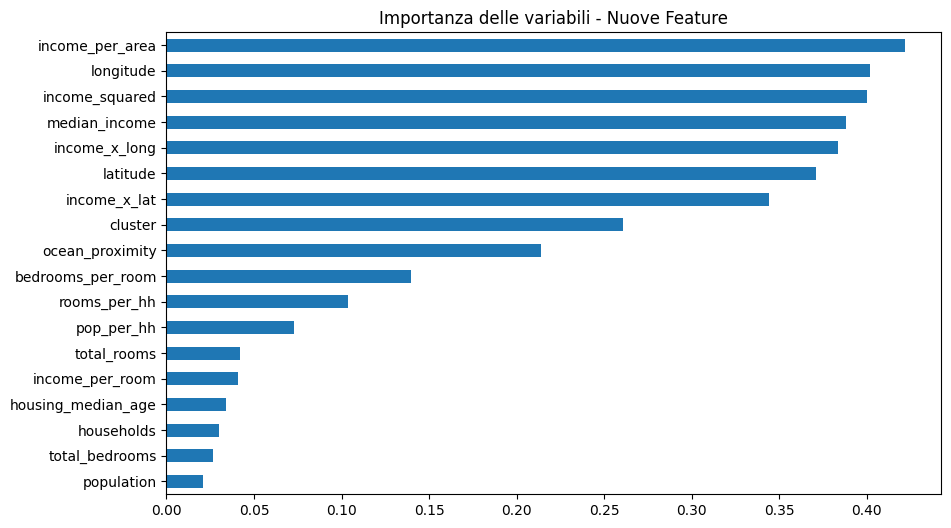

In [27]:

# prepariamo x new con le nuove feature create, per vedere se migliorano la MI rispetto a prima
X_new = df.drop('median_house_value', axis=1)
X_mi_new = X_new.copy()

# trasformo le variabili categoriche in numeriche con il factorize,
for colname in X_mi_new.select_dtypes(["object", "category"]):
    X_mi_new[colname], _ = X_mi_new[colname].factorize()

# gestione NaN
imputer = SimpleImputer(strategy='median')
X_mi_new = pd.DataFrame(imputer.fit_transform(X_mi_new), columns=X_mi_new.columns)

discrete_features_new = X_mi_new.dtypes == int

# funzione per calcolare la MI con le nuove feature già fatta sopra
mi_scores_new = make_mi_scores(X_mi_new, y, discrete_features_new)

# plt per visualizzare la nuova MI con le nuove feature
plt.figure(figsize=(10, 6), dpi=100)
mi_scores_new.sort_values(ascending=True).plot(kind='barh')
plt.title("Importanza delle variabili - Nuove Feature")
plt.show()



OSSERVANDO QUESTI VALORI DI IMPORTANZA NOTIAMO CHE ALCUNI ELEMENTI SONO MOLTO POCO RILEVANTI O ANCHE RICONDANTI, POTREMMO TOGLIERLI

DOPO AVERLO FATTO HO NOTATO CHE IL RMS PEGGIORAVA QUINDI HO EVITATO 

In [ ]:
#cols_to_drop=['population', 'households', 'total_bedrooms', 'housing_median_age']
#df.drop(columns=cols_to_drop, inplace=True)

Togliendo delle colonne però dobbiamo ricostruire sia le num_features del preprocessing e rirunniamo il preprocessing stesso per aggiornarlo. *non lo facciamo più*

In [ ]:
num_features = [
    'longitude', 'latitude', 'housing_median_age',  
    'total_rooms', 'total_bedrooms',                
    'population', 'households',                      
    'median_income', 'rooms_per_hh', 'bedrooms_per_room',
    'pop_per_hh', 'income_per_room', 'income_per_area',
    'income_squared', 'income_x_long', 'income_x_lat', 'cluster'
]


In [ ]:
df['rooms_per_hh']      = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['pop_per_hh']        = df['population'] / df['households']
df['income_per_room']   = df['median_income'] / df['total_rooms']
df['income_per_area']   = df['median_income'] / df['population']
df['income_squared']    = df['median_income'] ** 2
df['income_x_long']     = df['median_income'] * df['longitude']
df['income_x_lat']      = df['median_income'] * df['latitude']

# Clustering
cols_for_clustering = ['longitude', 'latitude', 'median_income']
X_km = StandardScaler().fit_transform(df[cols_for_clustering])
df['cluster'] = KMeans(n_clusters=5, n_init=10, random_state=42).fit_predict(X_km)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_hh,bedrooms_per_room,pop_per_hh,income_per_room,income_per_area,income_squared,income_x_long,income_x_lat,cluster
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556,0.009460,0.025855,69.308955,-1017.589196,315.358576,1
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842,0.001169,0.003457,68.913242,-1014.597108,314.291004,1
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260,0.004947,0.014632,52.669855,-887.144576,274.692590,1
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945,0.004429,0.010113,31.844578,-689.868975,213.591335,1
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467,0.002364,0.006807,14.793254,-470.197950,145.578670,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,5.045455,0.224625,2.560606,0.000937,0.001847,2.434536,-188.936727,61.600644,4
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,6.114035,0.215208,3.122807,0.003668,0.007182,6.537226,-309.909728,100.968032,4
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,5.205543,0.215173,2.325635,0.000754,0.001688,2.890000,-206.074000,67.031000,4
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,5.329513,0.219892,2.123209,0.001004,0.002520,3.486436,-226.528704,73.623696,4


In [49]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])


In [ ]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5,
                           scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Nuovo RMSE:", -grid_search.best_score_)
print("Best params:", grid_search.best_params_)


Nuovo RMSE: 49981.670795641396
Best params: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 200}


vediamo che da dei valori stranamente troppo alti, quindi cercando delle possibili motivazioni controlliamo le varie cose

In [65]:
# Calcola RMSE sul test set (come era il baseline)
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = grid_search.best_estimator_.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE test set:", rmse_test)



RMSE test set: 49979.84860621633


In [80]:
from xgboost import XGBRegressor

# Preprocessa tutto (XGBoost non vuole stringhe)
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# Encode ocean_proximity prima dello split
X['ocean_proximity'] = X['ocean_proximity'].astype('category').cat.codes

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Imputa NaN (total_bedrooms)
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns)


In [79]:
xgb = XGBRegressor(random_state=42)

param_grid_xgb = {
    'n_estimators':    [200, 300, 400],
    'learning_rate':   [0.08, 0.1, 0.12],
    'max_depth':       [5, 6, 7],
    'subsample':       [0.85, 0.9],
    'colsample_bytree':[0.85, 0.9],
    'reg_alpha':       [0, 0.1],
    'reg_lambda':      [1, 1.5],
}

grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5,
                        scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
grid_xgb.fit(X_train, y_train)

y_pred = grid_xgb.best_estimator_.predict(X_test)
print("RMSE Test:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Best params:", grid_xgb.best_params_)


Fitting 5 folds for each of 432 candidates, totalling 2160 fits


KeyboardInterrupt: 

ricontrollando i vecchi metodi per gridsearch, ho notato che quando lo facevo e mi aveva dato il valore molto più basso(36...) c'era stato un data leakage e quindi quello vero è questo di ora 

LEZIONE 5: OTTIMIZZAZIONE BAESYANA
=====================

l'Ottimizzazione baesyana cos'è e a cosa serve?
è la pratica di identificare e selezionare gli iperparametri ottimali da utilizzare nell'addestramento di un modello di machine learning. Se eseguita correttamente, riduce al minimo la funzione di perdita di un modello di machine learning, il che significa che le prestazioni del modello vengono addestrate per essere il più accurate possibile. (spiegazione trovata online)

In [83]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer


X = df.drop('median_house_value', axis=1)#X è il nostro dataset senza la colonna target
y = df['median_house_value']

X['ocean_proximity'] = X['ocean_proximity'].astype('category').cat.codes#encode della variabile categorica prima dello split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)#split 80/20

imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns)

#spazio di ricerca Bayesiana
search_space = {
    'n_estimators':      Integer(200, 1000),#variamo il numero di alberi per vedere se migliora la performance
    'learning_rate':     Real(0.01, 0.2, prior='log-uniform'),#variamo il learning rate per vedere se migliora la performance
    'max_depth':         Integer(3, 9),
    'subsample':         Real(0.5, 1.0),
    'colsample_bytree':  Real(0.3, 1.0),
    'min_child_weight':  Integer(1, 10),
    'reg_alpha':         Real(1e-5, 10.0, prior='log-uniform'),
    'reg_lambda':        Real(1e-5, 10.0, prior='log-uniform'),
}

#BayesSearchCV con XGBoost 
xgb = XGBRegressor(random_state=42, n_jobs=-1)

opt = BayesSearchCV(#opt è il nostro ottimizzatore bayesiano che cercherà i migliori iperparametri 
    xgb,
    search_spaces=search_space,
    n_iter=40,          # 40 combinazioni smart 
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

opt.fit(X_train, y_train)

# ── 4. Risultati ──
y_pred = opt.best_estimator_.predict(X_test)
print("RMSE Test:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Best params:", opt.best_params_)


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

RMSE Test: 43877.30515525892
nuovo record, e notando quali sono i parametri consigliati ci sono parametri come il max depth, subsample ecc che hanno toccato il bordo del range quindi conviene provarlo allargando le dimensioni dello spazio di ricerca

In [85]:
# n_estimators ha toccato il massimo (1000) → alzalo!
# reg_lambda ha toccato il massimo (10.0) → alzalo!

search_space_v2 = {
    'n_estimators':      Integer(500, 2000),    # ← era 200-1000
    'learning_rate':     Real(0.005, 0.1, prior='log-uniform'),
    'max_depth':         Integer(6, 10),        # ← stringe intorno a 8
    'subsample':         Real(0.8, 1.0),        # ← stringe intorno a 0.90
    'colsample_bytree':  Real(0.8, 1.0),        # ← stringe intorno a 0.93
    'min_child_weight':  Integer(1, 5),
    'reg_alpha':         Real(0.01, 1.0, prior='log-uniform'),
    'reg_lambda':        Real(1.0, 50.0, prior='log-uniform'),  # ← era fino a 10
}

xgb = XGBRegressor(random_state=42, n_jobs=-1)

opt = BayesSearchCV(#opt è il nostro ottimizzatore bayesiano che cercherà i migliori iperparametri 
    xgb,
    search_spaces=search_space_v2,
    n_iter=40,          # 40 combinazioni smart 
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

opt.fit(X_train, y_train)

#risultati v2
y_pred = opt.best_estimator_.predict(X_test)
print("RMSE Test:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Best params:", opt.best_params_)


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

RMSE Test: 44200.64752162515
Best params: OrderedDict({'colsample_bytree': 0.8, 'learning_rate': 0.026945484093010945, 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 1716, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'subsample': 0.8})

NOTIAMO QUINDI CHE ERA PIU' OTTIMALE QUELLO DI PRIMA QUINDI USEREMO QUELLO

In [86]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer


X = df.drop('median_house_value', axis=1)#X è il nostro dataset senza la colonna target
y = df['median_house_value']

X['ocean_proximity'] = X['ocean_proximity'].astype('category').cat.codes#encode della variabile categorica prima dello split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)#split 80/20

imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns)

#spazio di ricerca Bayesiana
search_space = {
    'n_estimators':      Integer(200, 1000),#variamo il numero di alberi per vedere se migliora la performance
    'learning_rate':     Real(0.01, 0.2, prior='log-uniform'),#variamo il learning rate per vedere se migliora la performance
    'max_depth':         Integer(3, 9),
    'subsample':         Real(0.5, 1.0),
    'colsample_bytree':  Real(0.3, 1.0),
    'min_child_weight':  Integer(1, 10),
    'reg_alpha':         Real(1e-5, 10.0, prior='log-uniform'),
    'reg_lambda':        Real(1e-5, 10.0, prior='log-uniform'),
}

#BayesSearchCV con XGBoost 
xgb = XGBRegressor(random_state=42, n_jobs=-1)

opt = BayesSearchCV(#opt è il nostro ottimizzatore bayesiano che cercherà i migliori iperparametri 
    xgb,
    search_spaces=search_space,
    n_iter=40,          # 40 combinazioni smart 
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

opt.fit(X_train, y_train)


y_pred = opt.best_estimator_.predict(X_test)
print("RMSE Test:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Best params:", opt.best_params_)


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi